In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# =====================================================
# 1. PREPARACIÓN DE DATOS (HETPROBIT DEFINITIVO)
# =====================================================
variables = [
    'Discapacidad', 'Log Ingreso', 'Horas no Estudio',
    'Esc. Jefe: Primaria', 'Esc. Jefe: Secundaria', 
    'Esc. Jefe: Preparatoria', 'Esc. Jefe: Licenciatura+', 
    'Internet', 'Hombre', 'Edad', 'Indígena', 'Urbano', 
    'Integrantes Hogar', 'Región: Centro-Norte', 'Región: Norte', 
    'Región: Norte-Occidente', 'Región: Sur', 'Razón Alumno/Esc',
    'Costo de oportunidad'
]

data = {
    'Variable': variables * 4,
    'Modelo': (['MS 2018'] * 19 + ['SUP 2018'] * 19 + 
               ['MS 2024'] * 19 + ['SUP 2024'] * 19),
    'Efecto': [
        # M1: MS 2018 (Hetprobit)
        -0.2328546, 0.0503778, -0.0045274, 0.0180553, 0.0495645, 0.1093892, 0.1240601, 
        0.1007039, -0.0455514, -0.0367237, 0.0013879, 0.0314106, -0.0144615, 
        -0.0465802, -0.0238711, 0.0167634, 0.0484629, 0.0077831, -0.0189793,

        # M2: SUP 2018 (Hetprobit) - ACTUALIZADO
        -0.213885, 0.0772327, -0.0049551, -0.0601058, -0.000669, 0.0762332, 0.1389274, 
        0.1282598, -0.0552879, -0.0510783, -0.0024142, 0.0432545, -0.0152657, 
        -0.0423054, -0.0216839, 0.0217287, 0.0248886, 0.0367279, -0.0408558,

        # M3: MS 2024 (Hetprobit)
        -0.2072737, 0.0532932,  -.0061259, -0.0516829, 0.0118722, 0.0753868, 0.1222066, 
        0.051355, -0.0530098, -0.0275919, 0.0065468, 0.0339902, -0.0100107, 
        -0.043007, -0.0463165, 0.001162, 0.0007024, 0.0128486, -0.0484886,

        # M4: SUP 2024 (Hetprobit)
        -0.1736037, 0.0702727, -0.0078994, -0.0632849, -0.0122905, 0.0599097, 0.0689742, 
        0.1097613, -0.046968, -0.0324065, -0.0005885, 0.0466105, -0.0172311, 
        -0.0240476, -0.0115898, 0.0008685, -0.0360602, 0.0274101, -0.1365875
    ],

    'SE': [
        # M1: MS 2018
        0.043932, 0.0062272, 0.0002549, 0.0154495, 0.0143481, 0.0183628, 0.0236701, 
        0.0120708, 0.0102079, 0.0053699, 0.0122431, 0.0126764, 0.0033273, 
        0.0182506, 0.0140706, 0.0144717, 0.0166598, 0.0034031, 0.0208685,

        # M2: SUP 2018 - ACTUALIZADO
        0.0229745, 0.0068949, 0.0001964, 0.016098, 0.0130182, 0.018683, 0.0185083, 
        0.0119628, 0.009318, 0.0023251, 0.012832, 0.0127716, 0.0030459, 
        0.0166339, 0.0153545, 0.0140498, 0.0155595, 0.0153273, 0.0282968,

        # M3: MS 2024
        0.033822, 0.0068844, 0.0002985, 0.0184296, 0.0165027, 0.0161251, 0.0171581, 
        0.0143294, 0.0096095, 0.0053343, 0.0133747, 0.0122085, 0.0035989, 
        0.0169504, 0.0141499, 0.0130404, 0.0132698, 0.0028931, 0.0144128,

        # M4: SUP 2024
        0.0249747, 0.0067039, 0.0001706, 0.0158953, 0.0128687, 0.0147568, 0.0159397, 
        0.0123928, 0.0089334, 0.0023198, 0.0130278, 0.0116604, 0.0033514, 
        0.0153041, 0.0165637, 0.0128989, 0.0130469, 0.0130518, 0.0323671
    ]
}

df = pd.DataFrame(data)

# ================================
# 2. VALORES t Y ESTILOS
# ================================
t_stats = {
    'MS 2018': [-5.30, 8.09, -17.76, 1.17, 3.45, 5.96, 5.24, 8.34, -4.46, -6.84, 0.11, 2.48, -4.35, -2.55, -1.70, 1.16, 2.91, 2.29, -0.91],
    'SUP 2018': [-9.31, 11.20, -25.23, -3.73, -0.05, 4.08, 7.51, 10.72, -5.93, -21.97, -0.19, 3.39, -5.01, -2.54, -1.41, 1.55, 1.60, 2.40, -1.44],
    'MS 2024': [-6.13, 7.74, -20.52, -2.80, 0.72, 4.68, 7.12, 3.58, -5.52, -5.17, 0.49, 2.78, -2.78, -2.54, -3.27, 0.09, 0.05, 4.44, -3.36],
    'SUP 2024': [-6.95, 10.48, -46.31, -3.98, -0.96, 4.06, 4.33, 8.86, -5.26, -13.97, -0.05, 4.00, -5.14, -1.57, -0.70, 0.07, -2.76, 2.10, -4.22]
}

df_t = pd.DataFrame(t_stats, index=variables)
df_efectos = df.pivot(index='Variable', columns='Modelo', values='Efecto').reindex(variables)
df_efectos = df_efectos[['MS 2018', 'SUP 2018', 'MS 2024', 'SUP 2024']]

def apply_color_by_t(data):
    color_mask = pd.DataFrame('', index=data.index, columns=data.columns)
    for col in data.columns:
        for idx in data.index:
            t = abs(df_t.loc[idx, col])
            if t == 0:
                 color_mask.loc[idx, col] = 'background-color: white; color: #BDBDBD'
            elif t >= 2.576:   # 1%
                color_mask.loc[idx, col] = 'background-color: #C8E6C9' 
            elif t >= 1.96:  # 5%
                color_mask.loc[idx, col] = 'background-color: #C8E6C9' 
            elif t >= 1.645: # 10%
                color_mask.loc[idx, col] = 'background-color: #FFF9C4' 
            else:
                color_mask.loc[idx, col] = 'background-color: #FFCDD2' 
    return color_mask

styled_df = df_efectos.style.apply(apply_color_by_t, axis=None) \
    .format(lambda x: "{:.2%}".format(x) if x != 0 else "-") \
    .set_caption("Impacto en Asistencia Escolar (dy/dx)") \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1A237E'), ('color', 'white'), ('font-family', 'Arial')]},
        {'selector': 'td', 'props': [('font-family', 'Arial'), ('text-align', 'center')]}
    ])

display(styled_df)

# =====================================================
# 3. TABLA DE PRECISIÓN DE LOS MODELOS Y MATRIZ (NUEVOS DATOS)
# =====================================================
data_precision = {
    'Modelo': [
        'Media Superior 2018 (Het)', 
        'Superior 2018 (Het)', 
        'Media Superior 2024 (Het)', 
        'Superior 2024 (Het)'
    ],
    'Muestra (N)': [9929, 16056, 10471, 18430],
    'AUC ROC': [0.8267, 0.8227, 0.8530, 0.8528],
    'Clasificación Correcta (%)': [0.8204, 0.7521, 0.8423, 0.7871], # (7672+4404)/16056 = 75.21%
    'Positivos Correctos': [7222, 4404, 7650, 5215],   
    'Negativos Correctos': [924, 7672, 1170, 9292],    
    'Falsos Positivos': [1407, 1709, 1231, 1858],      
    'Falsos Negativos': [376, 2271, 420, 2065]          
}

df_precision = pd.DataFrame(data_precision)

styled_precision = df_precision.style \
    .format({
        'Muestra (N)': "{:,}",
        'AUC ROC': "{:.4f}",
        'Clasificación Correcta (%)': "{:.2%}",
        'Positivos Correctos': "{:,}",
        'Negativos Correctos': "{:,}",
        'Falsos Positivos': "{:,}",
        'Falsos Negativos': "{:,}"
    }) \
    .set_properties(subset=['Positivos Correctos', 'Negativos Correctos'], 
                    **{'background-color': '#C8E6C9', 'color': 'black'}) \
    .set_properties(subset=['Falsos Positivos', 'Falsos Negativos'], 
                    **{'background-color': '#FFCDD2', 'color': 'black'}) \
    .set_caption("Precisión Predictiva y Matriz de Confusión (Hetprobit Final)") \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1A237E'), ('color', 'white'), ('font-family', 'Arial'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('font-family', 'Arial'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '14pt'), ('font-weight', 'bold'), ('color', '#1A237E'), ('margin-bottom', '10px')]}
    ]) \
    .hide(axis="index")

display(styled_precision)

# =====================================================
# 4. FOREST PLOT TOP 8 DETERMINANTES (2x2)
# =====================================================
df_sig = []
for mod in df['Modelo'].unique():
    for i, var in enumerate(variables):
        effect = df[(df['Modelo'] == mod) & (df['Variable'] == var)]['Efecto'].values[0]
        t_val = t_stats[mod][i]
        
        if abs(t_val) >= 1.96 and effect != 0:
            df_sig.append({'Modelo': mod, 'Variable': var, 'Efecto': effect * 100, 'AbsEfecto': abs(effect * 100)})

df_sig = pd.DataFrame(df_sig)

fig, axes = plt.subplots(2, 2, figsize=(18, 14), dpi=150, constrained_layout=True)
fig.suptitle("Top 8 Determinantes Más Importantes y Significativos por Nivel y Año", 
             fontsize=22, fontweight='bold', color='#1A237E')
axes = axes.flatten()
models = ['MS 2018', 'SUP 2018', 'MS 2024', 'SUP 2024']

for idx, ax in enumerate(axes):
    mod = models[idx]
    df_mod = df_sig[df_sig['Modelo'] == mod].sort_values('AbsEfecto', ascending=False).head(8)
    df_mod = df_mod.sort_values('Efecto', ascending=True)
    
    etiquetas_ajustadas = [textwrap.fill(var, width=18) for var in df_mod['Variable']]
    colors = ['#EF5350' if x < 0 else '#66BB6A' for x in df_mod['Efecto']]
    
    bars = ax.barh(etiquetas_ajustadas, df_mod['Efecto'], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(f'{mod}', fontsize=18, fontweight='bold', pad=15)
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Impacto en la Probabilidad (pp)', fontsize=13)
    ax.tick_params(axis='y', labelsize=12)
    
    max_val = df_mod['Efecto'].max()
    min_val = df_mod['Efecto'].min()
    padding = (max_val - min_val) * 0.25 
    ax.set_xlim(min_val - padding, max_val + padding)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    for i, (val, var) in enumerate(zip(df_mod['Efecto'], df_mod['Variable'])):
        align = 'left' if val > 0 else 'right'
        offset = padding * 0.15 if val > 0 else -padding * 0.15
        ax.text(val + offset, i, f'{val:+.1f} pp', va='center', ha=align, 
                fontsize=12, fontweight='bold', color='#333333')

plt.show()

Modelo,MS 2018,SUP 2018,MS 2024,SUP 2024
Variable,,,,
Discapacidad,-23.29%,-21.39%,-20.73%,-17.36%
Log Ingreso,5.04%,7.72%,5.33%,7.03%
Horas no Estudio,-0.45%,-0.50%,-0.61%,-0.79%
Esc. Jefe: Primaria,1.81%,-6.01%,-5.17%,-6.33%
Esc. Jefe: Secundaria,4.96%,-0.07%,1.19%,-1.23%
Esc. Jefe: Preparatoria,10.94%,7.62%,7.54%,5.99%
Esc. Jefe: Licenciatura+,12.41%,13.89%,12.22%,6.90%
Internet,10.07%,12.83%,5.14%,10.98%
Hombre,-4.56%,-5.53%,-5.30%,-4.70%


Modelo,Muestra (N),AUC ROC,Clasificación Correcta (%),Positivos Correctos,Negativos Correctos,Falsos Positivos,Falsos Negativos
Media Superior 2018 (Het),"9,929",0.8267,82.04%,"7,222",924,"1,407",376
Superior 2018 (Het),"16,056",0.8227,75.21%,"4,404","7,672","1,709","2,271"
Media Superior 2024 (Het),"10,471",0.8530,84.23%,"7,650","1,170","1,231",420
Superior 2024 (Het),"18,430",0.8528,78.71%,"5,215","9,292","1,858","2,065"


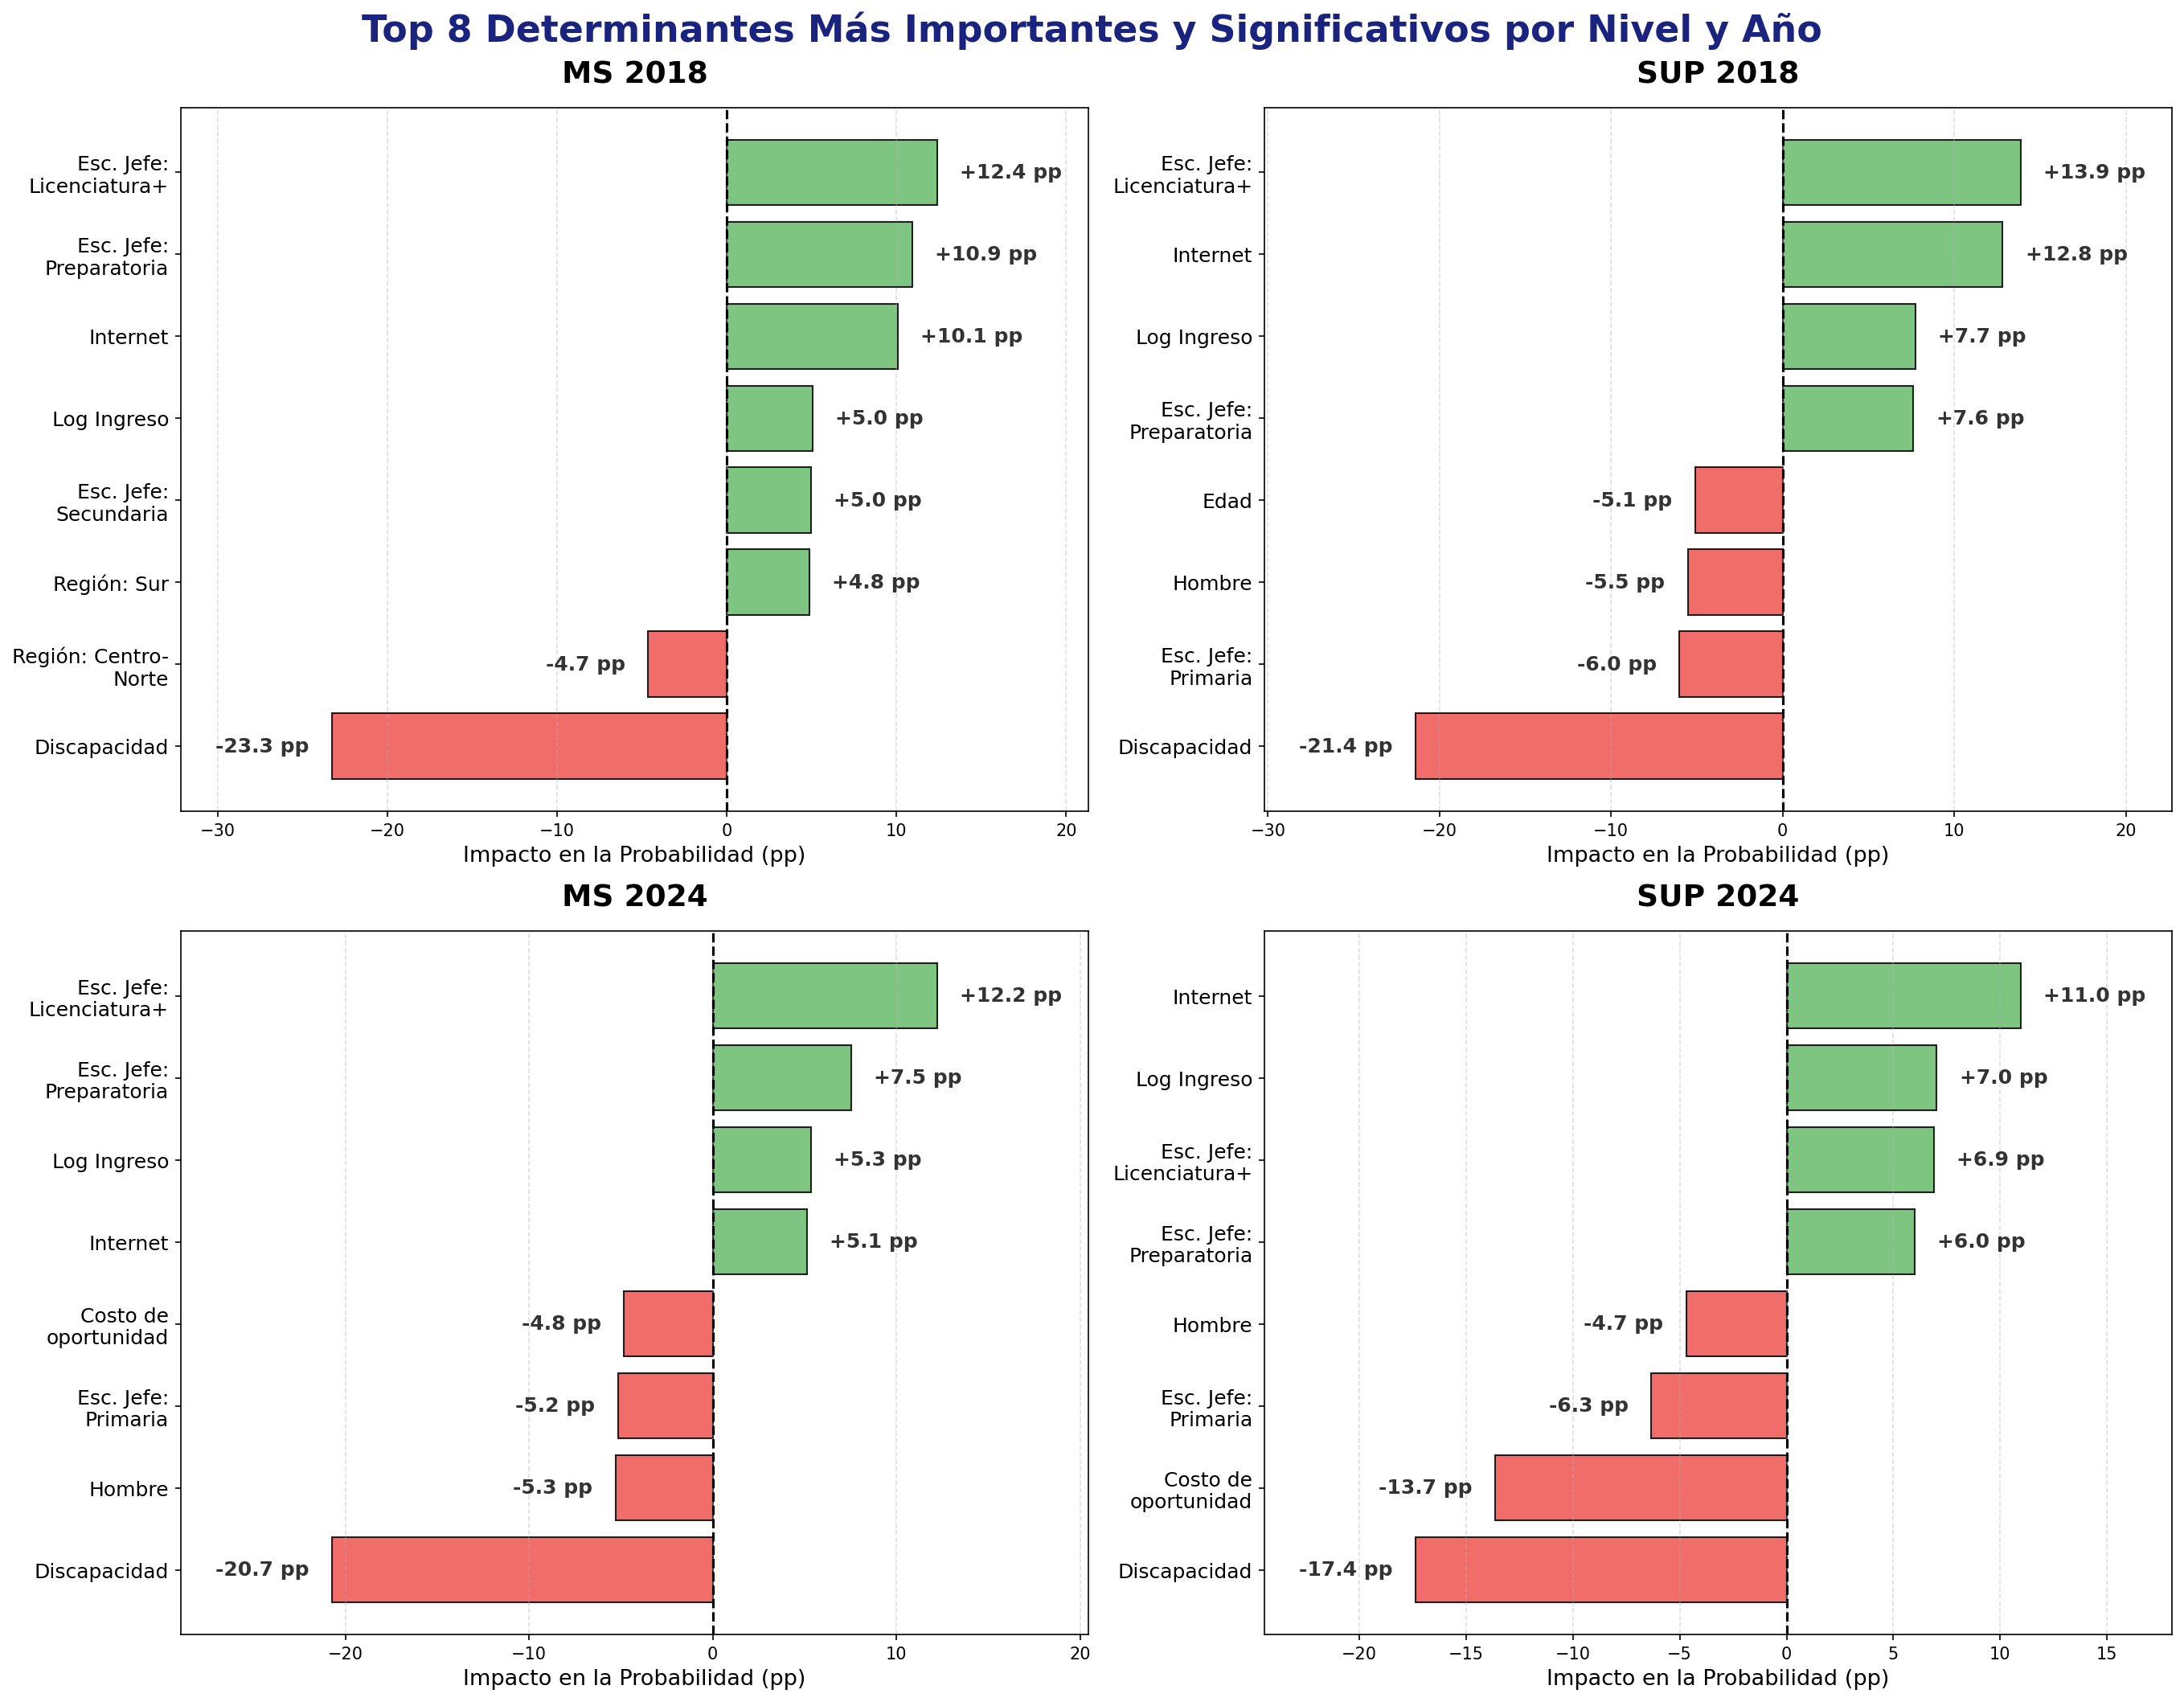

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# =====================================================
# 1. PREPARACIÓN DE DATOS (HETPROBIT DEFINITIVO)
# =====================================================
variables = [
    'Discapacidad', 'Log Ingreso', 'Horas no Estudio',
    'Esc. Jefe: Primaria', 'Esc. Jefe: Secundaria', 
    'Esc. Jefe: Preparatoria', 'Esc. Jefe: Licenciatura+', 
    'Internet', 'Hombre', 'Edad', 'Indígena', 'Urbano', 
    'Integrantes Hogar', 'Región: Centro-Norte', 'Región: Norte', 
    'Región: Norte-Occidente', 'Región: Sur', 'Razón Alumno/Esc',
    'Costo de oportunidad'
]

data = {
    'Variable': variables * 4,
    'Modelo': (['MS 2018'] * 19 + ['SUP 2018'] * 19 + 
               ['MS 2024'] * 19 + ['SUP 2024'] * 19),
    'Efecto': [
        # M1: MS 2018 (Hetprobit)
        -0.2328546, 0.0503778, -0.0045274, 0.0180553, 0.0495645, 0.1093892, 0.1240601, 
        0.1007039, -0.0455514, -0.0367237, 0.0013879, 0.0314106, -0.0144615, 
        -0.0465802, -0.0238711, 0.0167634, 0.0484629, 0.0077831, -0.0189793,

        # M2: SUP 2018 (Hetprobit) - ACTUALIZADO
        -0.213885, 0.0772327, -0.0049551, -0.0601058, -0.000669, 0.0762332, 0.1389274, 
        0.1282598, -0.0552879, -0.0510783, -0.0024142, 0.0432545, -0.0152657, 
        -0.0423054, -0.0216839, 0.0217287, 0.0248886, 0.0367279, -0.0408558,

        # M3: MS 2024 (Hetprobit)
        -0.2072737, 0.0532932,  -.0061259, -0.0516829, 0.0118722, 0.0753868, 0.1222066, 
        0.051355, -0.0530098, -0.0275919, 0.0065468, 0.0339902, -0.0100107, 
        -0.043007, -0.0463165, 0.001162, 0.0007024, 0.0128486, -0.0484886,

        # M4: SUP 2024 (Hetprobit)
        -0.1736037, 0.0702727, -0.0078994, -0.0632849, -0.0122905, 0.0599097, 0.0689742, 
        0.1097613, -0.046968, -0.0324065, -0.0005885, 0.0466105, -0.0172311, 
        -0.0240476, -0.0115898, 0.0008685, -0.0360602, 0.0274101, -0.1365875
    ],

    'SE': [
        # M1: MS 2018
        0.043932, 0.0062272, 0.0002549, 0.0154495, 0.0143481, 0.0183628, 0.0236701, 
        0.0120708, 0.0102079, 0.0053699, 0.0122431, 0.0126764, 0.0033273, 
        0.0182506, 0.0140706, 0.0144717, 0.0166598, 0.0034031, 0.0208685,

        # M2: SUP 2018 - ACTUALIZADO
        0.0229745, 0.0068949, 0.0001964, 0.016098, 0.0130182, 0.018683, 0.0185083, 
        0.0119628, 0.009318, 0.0023251, 0.012832, 0.0127716, 0.0030459, 
        0.0166339, 0.0153545, 0.0140498, 0.0155595, 0.0153273, 0.0282968,

        # M3: MS 2024
        0.033822, 0.0068844, 0.0002985, 0.0184296, 0.0165027, 0.0161251, 0.0171581, 
        0.0143294, 0.0096095, 0.0053343, 0.0133747, 0.0122085, 0.0035989, 
        0.0169504, 0.0141499, 0.0130404, 0.0132698, 0.0028931, 0.0144128,

        # M4: SUP 2024
        0.0249747, 0.0067039, 0.0001706, 0.0158953, 0.0128687, 0.0147568, 0.0159397, 
        0.0123928, 0.0089334, 0.0023198, 0.0130278, 0.0116604, 0.0033514, 
        0.0153041, 0.0165637, 0.0128989, 0.0130469, 0.0130518, 0.0323671
    ]
}

df = pd.DataFrame(data)

# ================================
# 2. VALORES t Y ESTILOS
# ================================
t_stats = {
    'MS 2018': [-5.30, 8.09, -17.76, 1.17, 3.45, 5.96, 5.24, 8.34, -4.46, -6.84, 0.11, 2.48, -4.35, -2.55, -1.70, 1.16, 2.91, 2.29, -0.91],
    'SUP 2018': [-9.31, 11.20, -25.23, -3.73, -0.05, 4.08, 7.51, 10.72, -5.93, -21.97, -0.19, 3.39, -5.01, -2.54, -1.41, 1.55, 1.60, 2.40, -1.44],
    'MS 2024': [-6.13, 7.74, -20.52, -2.80, 0.72, 4.68, 7.12, 3.58, -5.52, -5.17, 0.49, 2.78, -2.78, -2.54, -3.27, 0.09, 0.05, 4.44, -3.36],
    'SUP 2024': [-6.95, 10.48, -46.31, -3.98, -0.96, 4.06, 4.33, 8.86, -5.26, -13.97, -0.05, 4.00, -5.14, -1.57, -0.70, 0.07, -2.76, 2.10, -4.22]
}

df_t = pd.DataFrame(t_stats, index=variables)
df_efectos = df.pivot(index='Variable', columns='Modelo', values='Efecto').reindex(variables)
df_efectos = df_efectos[['MS 2018', 'SUP 2018', 'MS 2024', 'SUP 2024']]

def apply_color_by_t(data):
    color_mask = pd.DataFrame('', index=data.index, columns=data.columns)
    for col in data.columns:
        for idx in data.index:
            t = abs(df_t.loc[idx, col])
            if t == 0:
                 color_mask.loc[idx, col] = 'background-color: white; color: #BDBDBD'
            elif t >= 2.576:   # 1%
                color_mask.loc[idx, col] = 'background-color: #C8E6C9' 
            elif t >= 1.96:  # 5%
                color_mask.loc[idx, col] = 'background-color: #C8E6C9' 
            elif t >= 1.645: # 10%
                color_mask.loc[idx, col] = 'background-color: #FFF9C4' 
            else:
                color_mask.loc[idx, col] = 'background-color: #FFCDD2' 
    return color_mask

styled_df = df_efectos.style.apply(apply_color_by_t, axis=None) \
    .format(lambda x: "{:.2%}".format(x) if x != 0 else "-") \
    .set_caption("Impacto en Asistencia Escolar (dy/dx)") \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1A237E'), ('color', 'white'), ('font-family', 'Arial')]},
        {'selector': 'td', 'props': [('font-family', 'Arial'), ('text-align', 'center')]}
    ])

display(styled_df)

# =====================================================
# 3. TABLA DE PRECISIÓN DE LOS MODELOS Y MATRIZ (NUEVOS DATOS)
# =====================================================
data_precision = {
    'Modelo': [
        'Media Superior 2018 (Het)', 
        'Superior 2018 (Het)', 
        'Media Superior 2024 (Het)', 
        'Superior 2024 (Het)'
    ],
    'Muestra (N)': [9929, 16056, 10471, 18430],
    'AUC ROC': [0.8267, 0.8227, 0.8530, 0.8528],
    'Clasificación Correcta (%)': [0.8204, 0.7521, 0.8423, 0.7871], # (7672+4404)/16056 = 75.21%
    'Positivos Correctos': [7222, 4404, 7650, 5215],   
    'Negativos Correctos': [924, 7672, 1170, 9292],    
    'Falsos Positivos': [1407, 1709, 1231, 1858],      
    'Falsos Negativos': [376, 2271, 420, 2065]          
}

df_precision = pd.DataFrame(data_precision)

styled_precision = df_precision.style \
    .format({
        'Muestra (N)': "{:,}",
        'AUC ROC': "{:.4f}",
        'Clasificación Correcta (%)': "{:.2%}",
        'Positivos Correctos': "{:,}",
        'Negativos Correctos': "{:,}",
        'Falsos Positivos': "{:,}",
        'Falsos Negativos': "{:,}"
    }) \
    .set_properties(subset=['Positivos Correctos', 'Negativos Correctos'], 
                    **{'background-color': '#C8E6C9', 'color': 'black'}) \
    .set_properties(subset=['Falsos Positivos', 'Falsos Negativos'], 
                    **{'background-color': '#FFCDD2', 'color': 'black'}) \
    .set_caption("Precisión Predictiva y Matriz de Confusión (Hetprobit Final)") \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1A237E'), ('color', 'white'), ('font-family', 'Arial'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('font-family', 'Arial'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '14pt'), ('font-weight', 'bold'), ('color', '#1A237E'), ('margin-bottom', '10px')]}
    ]) \
    .hide(axis="index")

display(styled_precision)

# =====================================================
# 4. FOREST PLOT TOP 8 DETERMINANTES (2x2)
# =====================================================
df_sig = []
for mod in df['Modelo'].unique():
    for i, var in enumerate(variables):
        effect = df[(df['Modelo'] == mod) & (df['Variable'] == var)]['Efecto'].values[0]
        t_val = t_stats[mod][i]
        
        if abs(t_val) >= 1.96 and effect != 0:
            df_sig.append({'Modelo': mod, 'Variable': var, 'Efecto': effect * 100, 'AbsEfecto': abs(effect * 100)})

df_sig = pd.DataFrame(df_sig)

fig, axes = plt.subplots(2, 2, figsize=(18, 14), dpi=150, constrained_layout=True)
fig.suptitle("Top 8 Determinantes Más Importantes y Significativos por Nivel y Año", 
             fontsize=22, fontweight='bold', color='#1A237E')
axes = axes.flatten()
models = ['MS 2018', 'SUP 2018', 'MS 2024', 'SUP 2024']

for idx, ax in enumerate(axes):
    mod = models[idx]
    df_mod = df_sig[df_sig['Modelo'] == mod].sort_values('AbsEfecto', ascending=False).head(8)
    df_mod = df_mod.sort_values('Efecto', ascending=True)
    
    etiquetas_ajustadas = [textwrap.fill(var, width=18) for var in df_mod['Variable']]
    colors = ['#EF5350' if x < 0 else '#66BB6A' for x in df_mod['Efecto']]
    
    bars = ax.barh(etiquetas_ajustadas, df_mod['Efecto'], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(f'{mod}', fontsize=18, fontweight='bold', pad=15)
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Impacto en la Probabilidad (pp)', fontsize=13)
    ax.tick_params(axis='y', labelsize=12)
    
    max_val = df_mod['Efecto'].max()
    min_val = df_mod['Efecto'].min()
    padding = (max_val - min_val) * 0.25 
    ax.set_xlim(min_val - padding, max_val + padding)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    for i, (val, var) in enumerate(zip(df_mod['Efecto'], df_mod['Variable'])):
        align = 'left' if val > 0 else 'right'
        offset = padding * 0.15 if val > 0 else -padding * 0.15
        ax.text(val + offset, i, f'{val:+.1f} pp', va='center', ha=align, 
                fontsize=12, fontweight='bold', color='#333333')

plt.show()

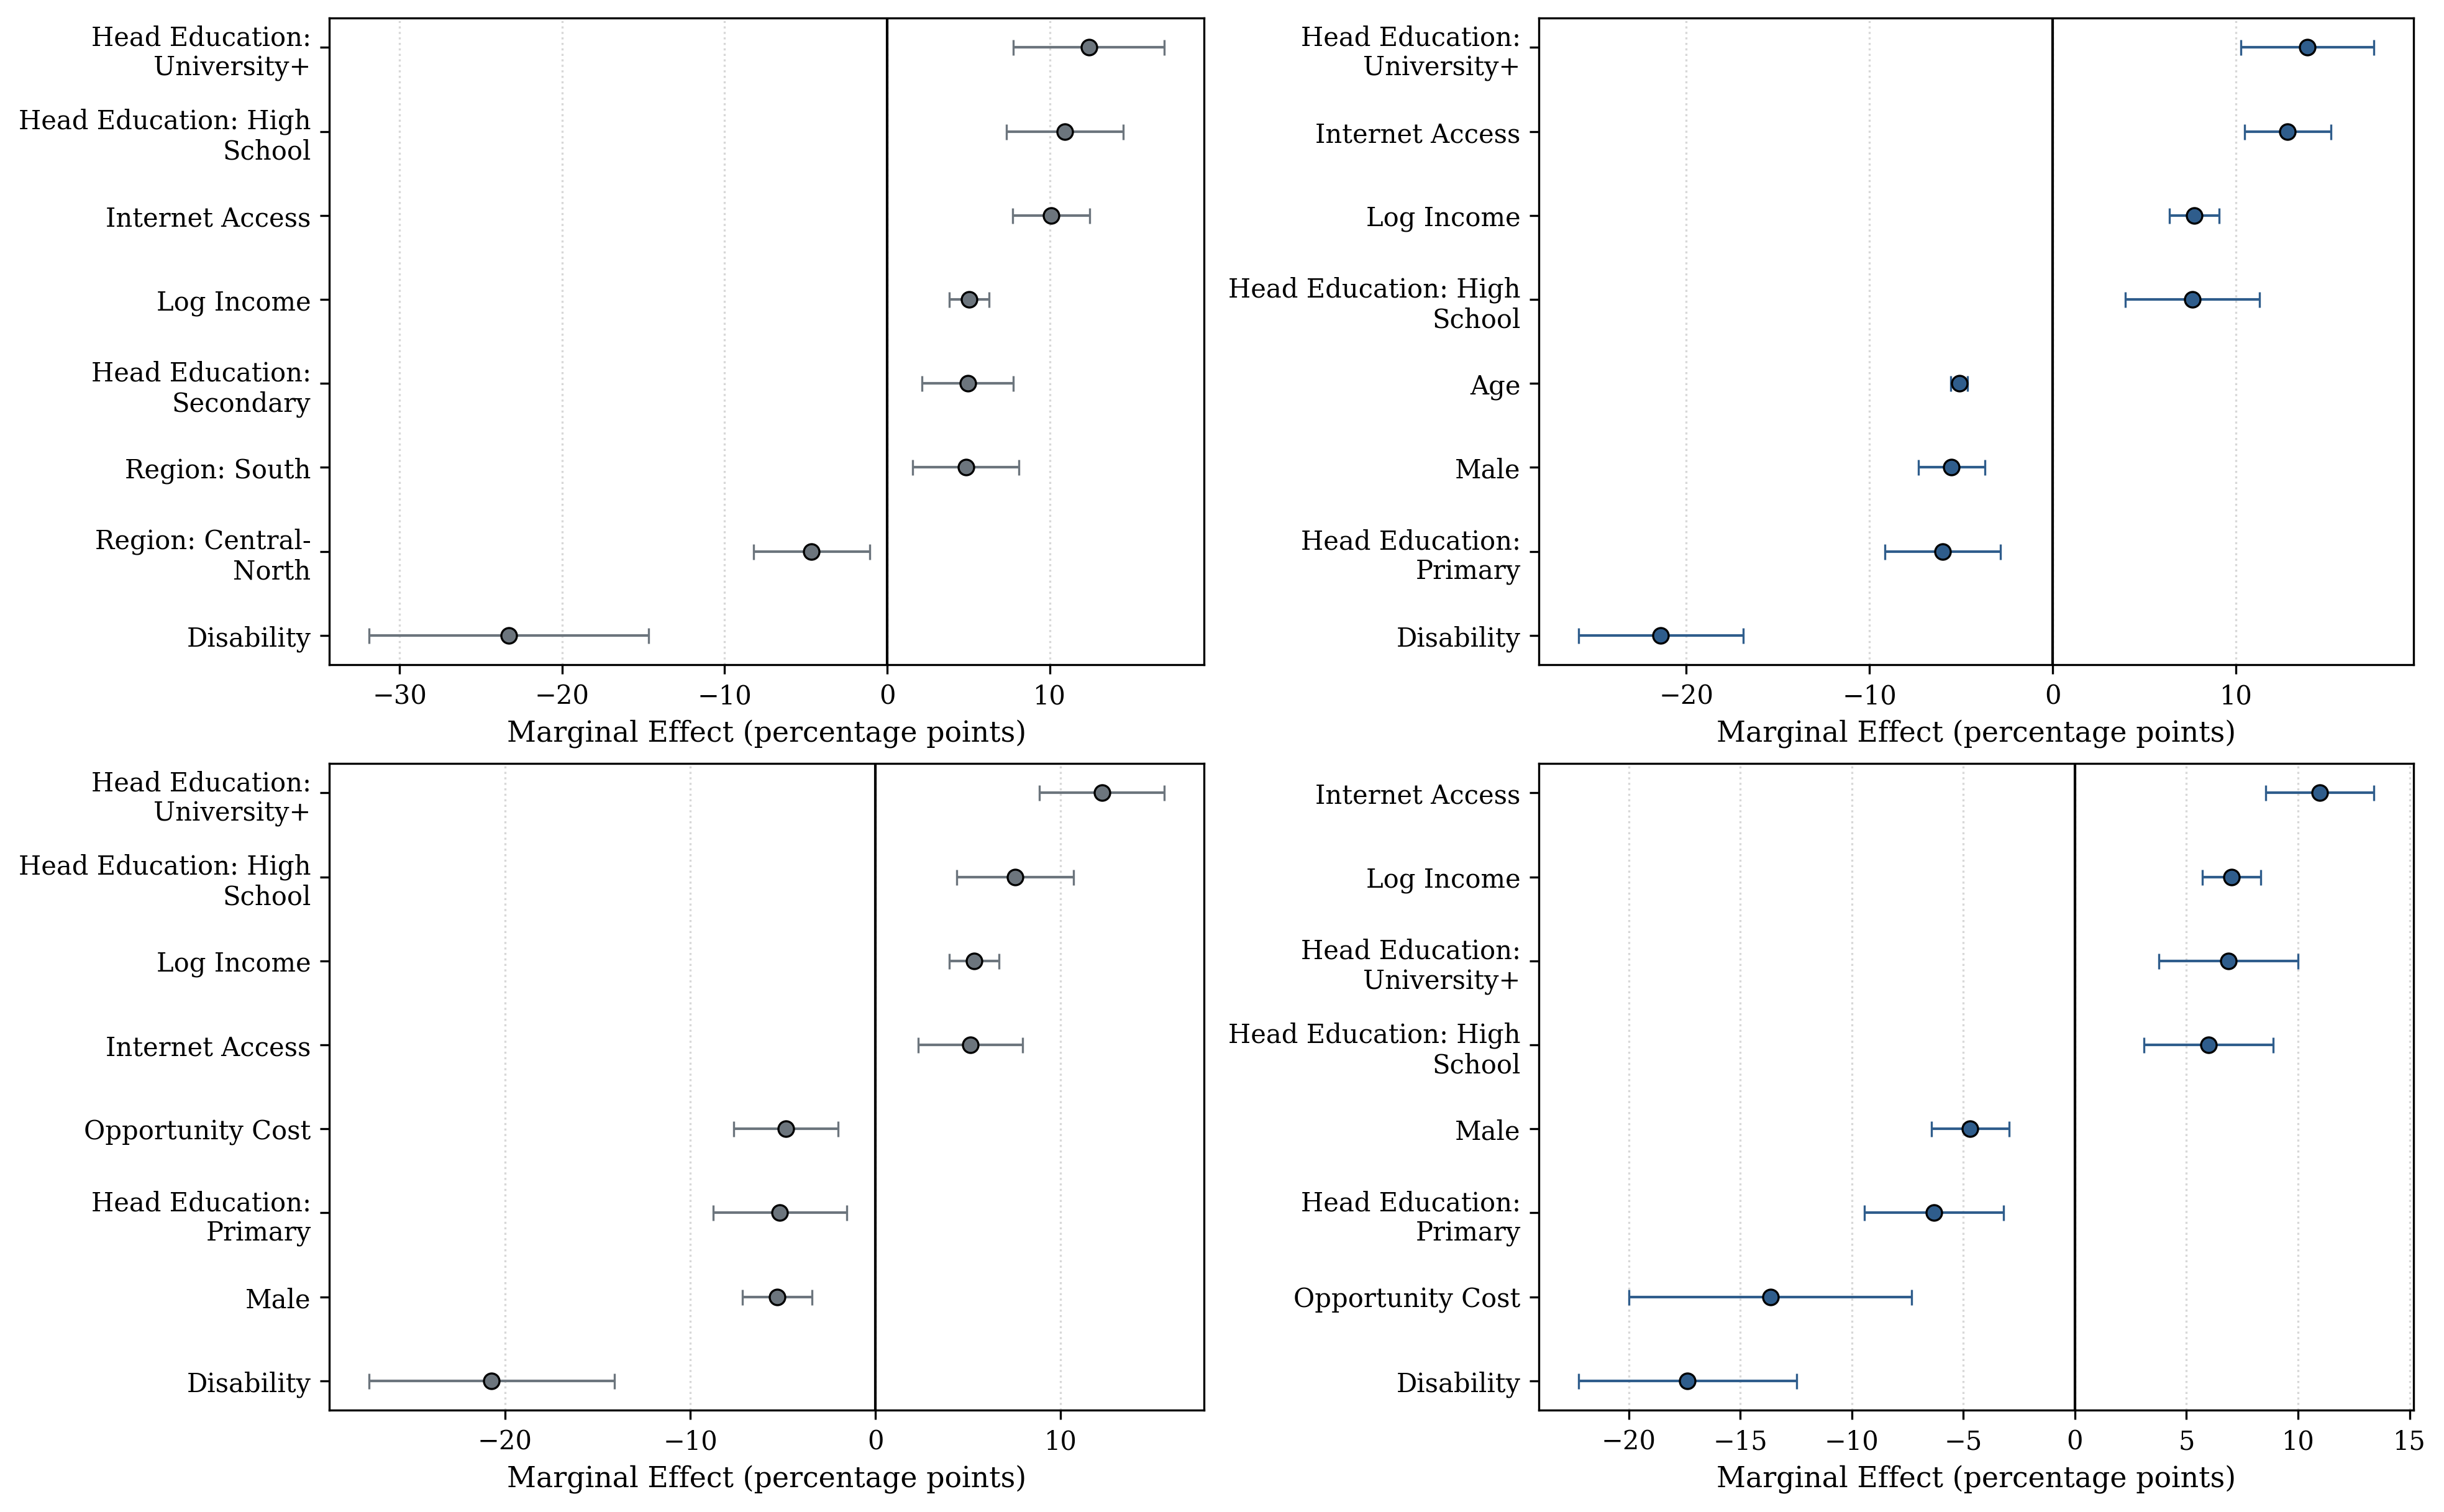

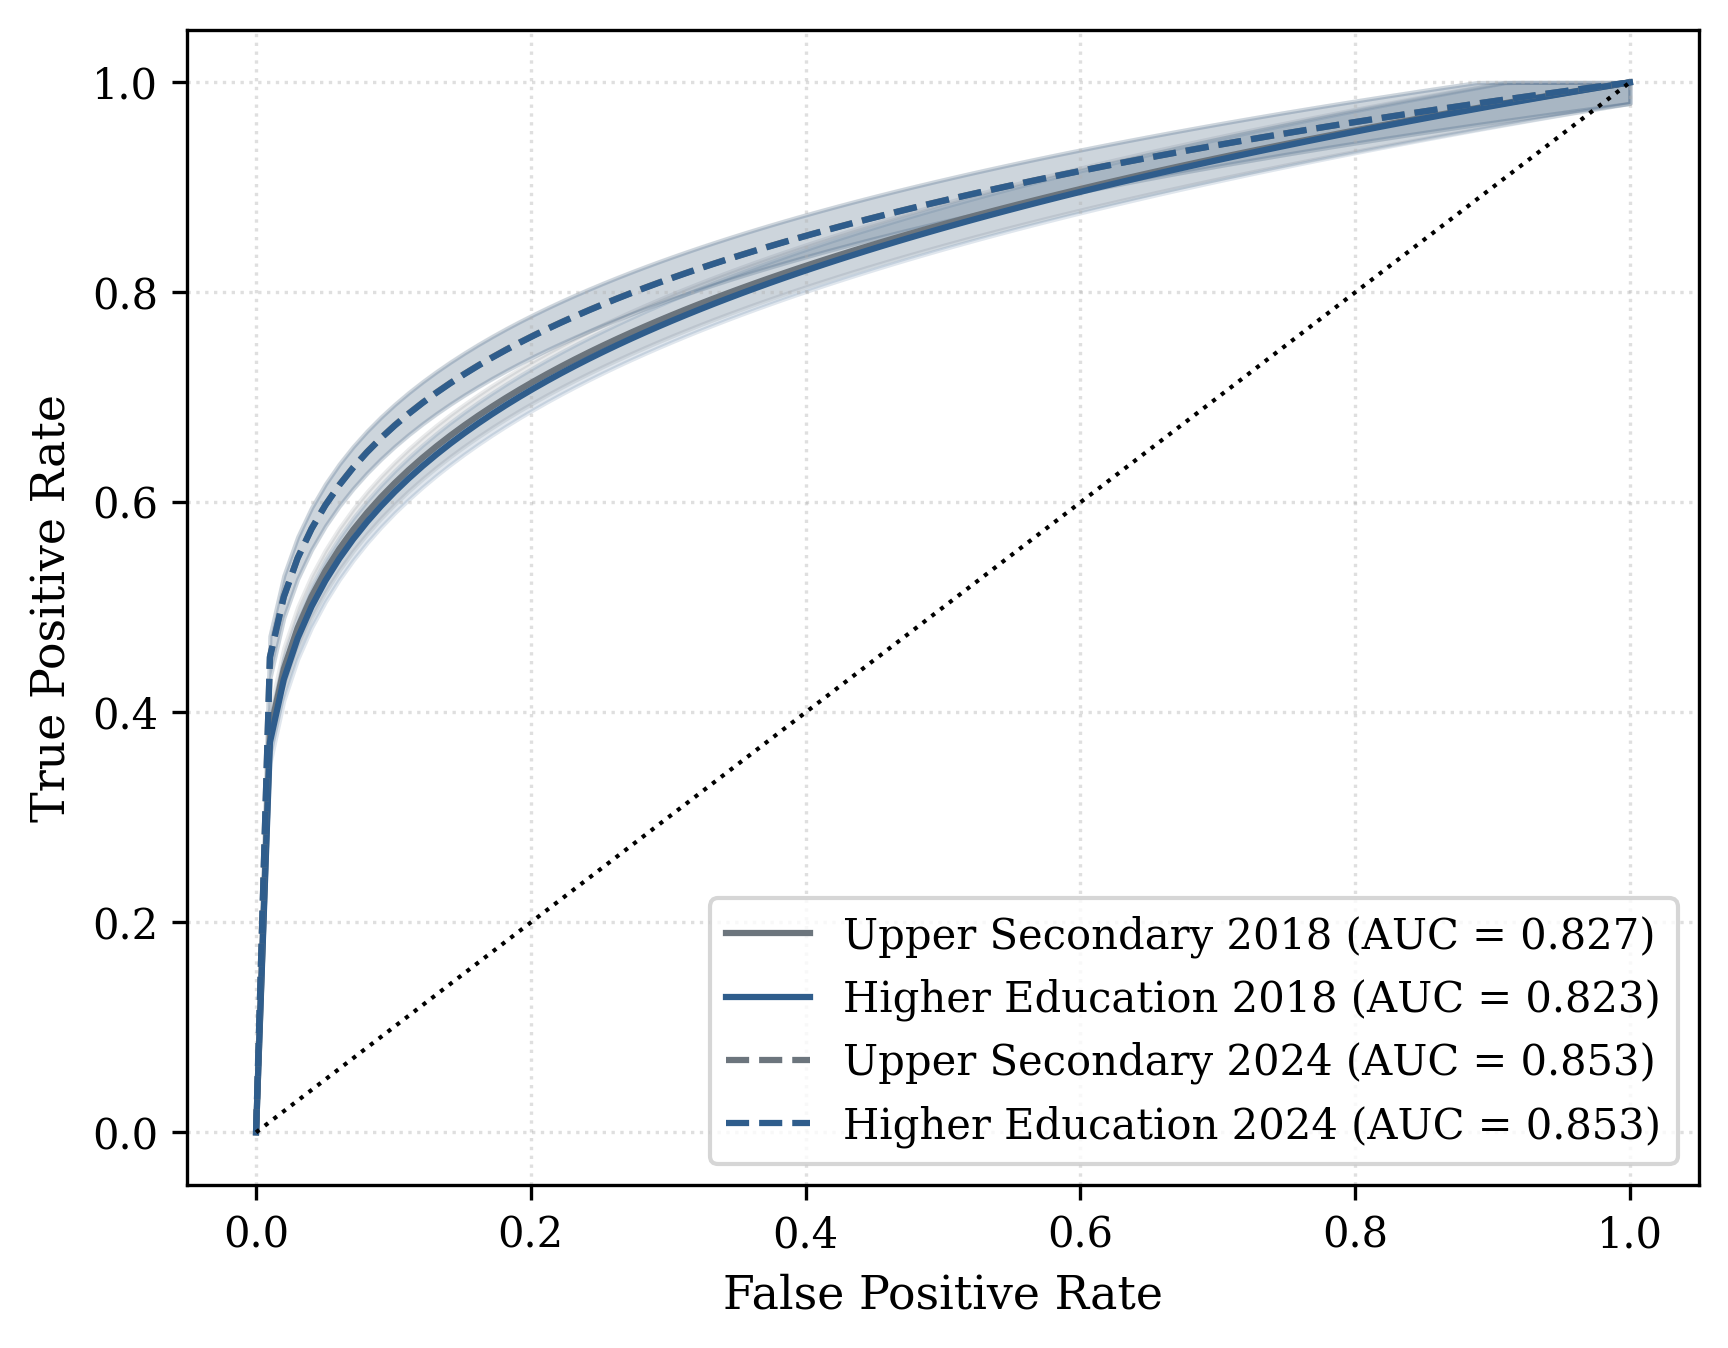

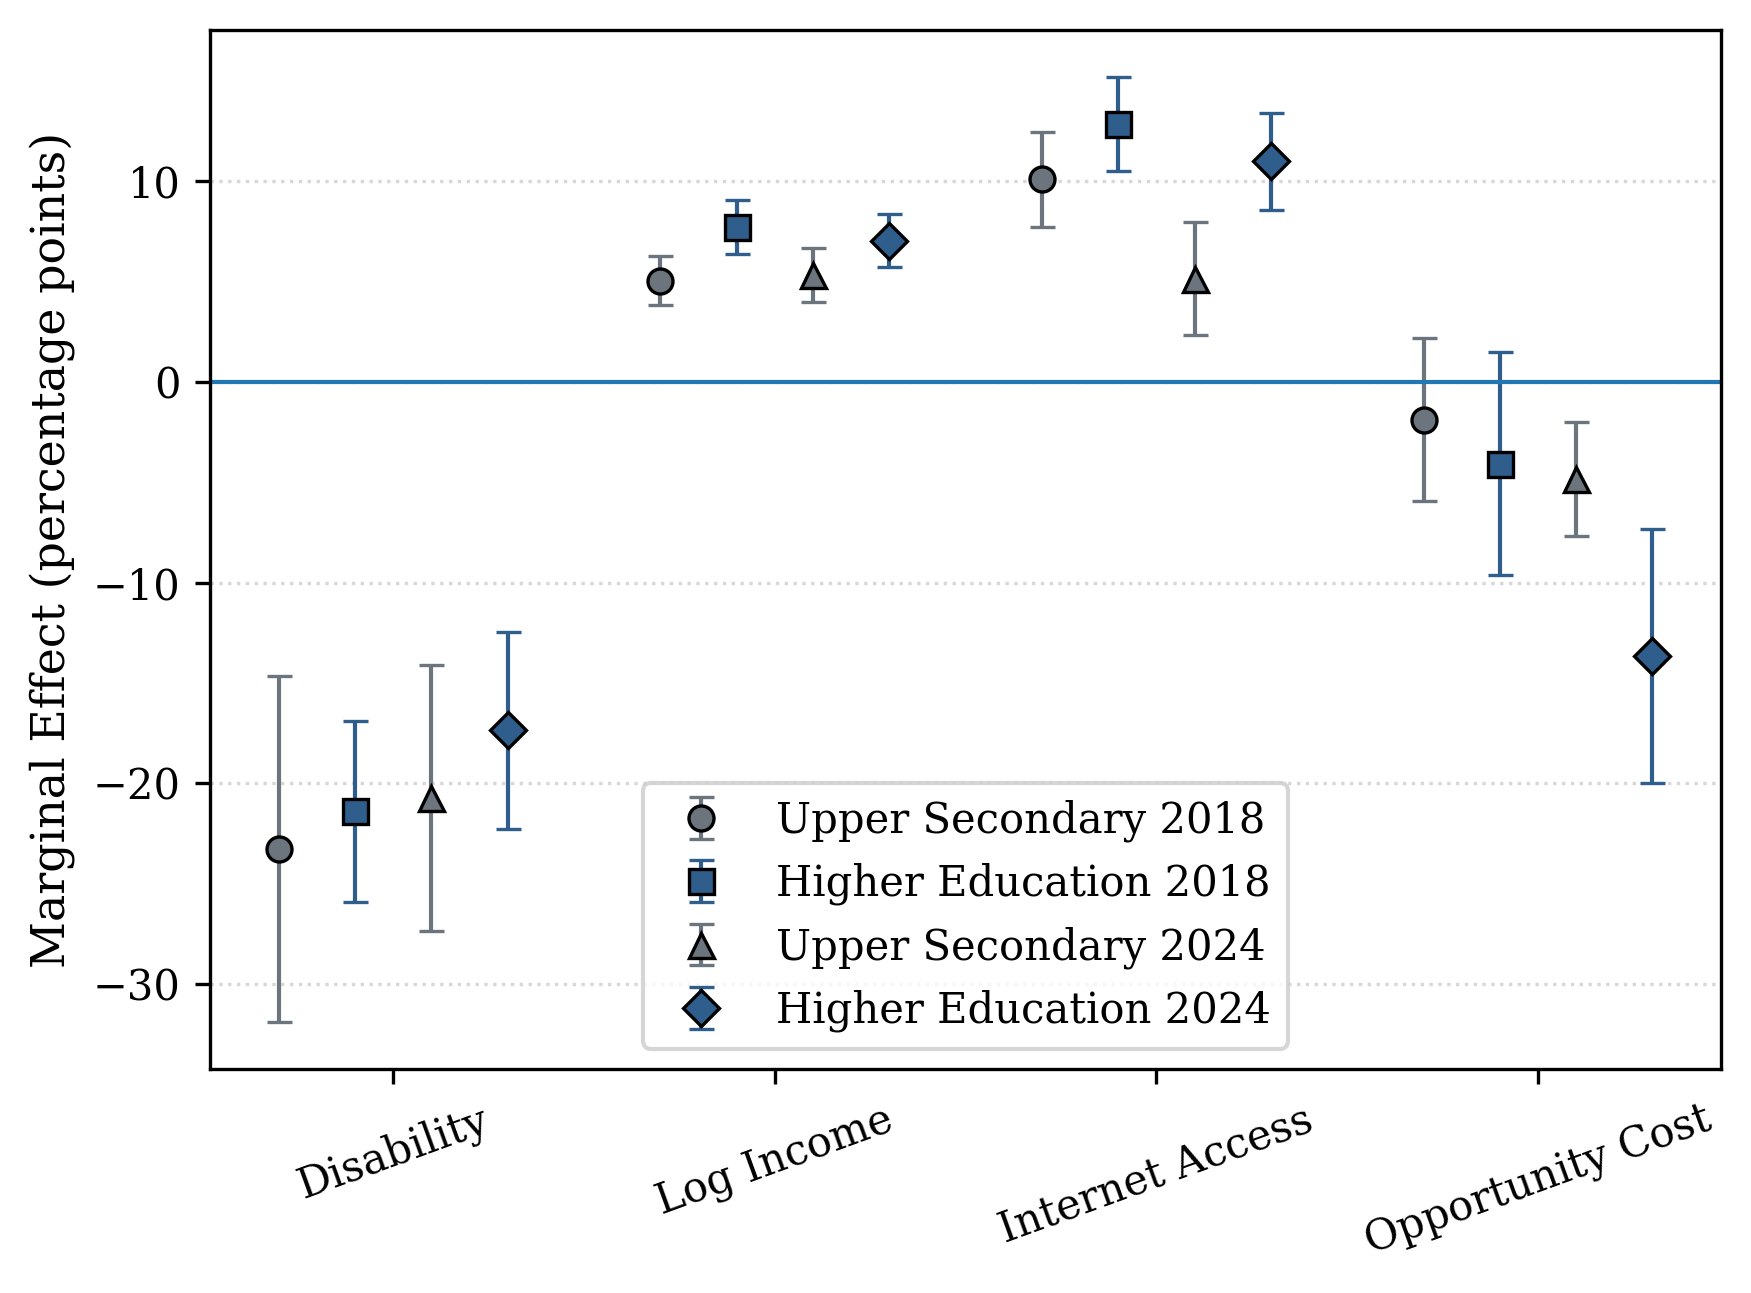

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# =====================================================
# UNIFIED ACADEMIC STYLE (Journal / Conference Ready)
# =====================================================

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATA RECONSTRUCTION
# =====================================================

variables = [
    'Disability',
    'Log Income',
    'Non-study Hours',
    'Head Education: Primary',
    'Head Education: Secondary',
    'Head Education: High School',
    'Head Education: University+',
    'Internet Access',
    'Male',
    'Age',
    'Indigenous',
    'Urban',
    'Household Size',
    'Region: Central-North',
    'Region: North',
    'Region: Northwest',
    'Region: South',
    'Student-School Ratio',
    'Opportunity Cost'
]

data = {
    'Variable': variables * 4,
    'Model': (
        ['Upper Secondary 2018'] * 19 +
        ['Higher Education 2018'] * 19 +
        ['Upper Secondary 2024'] * 19 +
        ['Higher Education 2024'] * 19
    ),
    'Effect': [

        -0.2328, 0.0503, -0.0045, 0.0180, 0.0495,
        0.1093, 0.1240, 0.1007, -0.0455, -0.0367,
        0.0013, 0.0314, -0.0144, -0.0465, -0.0238,
        0.0167, 0.0484, 0.0077, -0.0189,

        -0.2138, 0.0772, -0.0049, -0.0601, -0.0006,
        0.0762, 0.1389, 0.1282, -0.0552, -0.0510,
        -0.0024, 0.0432, -0.0152, -0.0423, -0.0216,
        0.0217, 0.0248, 0.0367, -0.0408,

        -0.2072, 0.0532, -0.0061, -0.0516, 0.0118,
        0.0753, 0.1222, 0.0513, -0.0530, -0.0275,
        0.0065, 0.0339, -0.0100, -0.0430, -0.0463,
        0.0011, 0.0007, 0.0128, -0.0484,

        -0.1736, 0.0702, -0.0078, -0.0632, -0.0122,
        0.0599, 0.0689, 0.1097, -0.0469, -0.0324,
        -0.0005, 0.0466, -0.0172, -0.0240, -0.0115,
        0.0008, -0.0360, 0.0274, -0.1365
    ]
}

df = pd.DataFrame(data)

# =====================================================
# T-STATISTICS
# =====================================================

t_stats = {
    'Upper Secondary 2018': [-5.30, 8.09, -17.76, 1.17, 3.45, 5.96, 5.24, 8.34, -4.46, -6.84, 0.11, 2.48, -4.35, -2.55, -1.70, 1.16, 2.91, 2.29, -0.91],
    'Higher Education 2018': [-9.31, 11.20, -25.23, -3.73, -0.05, 4.08, 7.51, 10.72, -5.93, -21.97, -0.19, 3.39, -5.01, -2.54, -1.41, 1.55, 1.60, 2.40, -1.44],
    'Upper Secondary 2024': [-6.13, 7.74, -20.52, -2.80, 0.72, 4.68, 7.12, 3.58, -5.52, -5.17, 0.49, 2.78, -2.78, -2.54, -3.27, 0.09, 0.05, 4.44, -3.36],
    'Higher Education 2024': [-6.95, 10.48, -46.31, -3.98, -0.96, 4.06, 4.33, 8.86, -5.26, -13.97, -0.05, 4.00, -5.14, -1.57, -0.70, 0.07, -2.76, 2.10, -4.22]
}

# =====================================================
# FUNCTION: COMPUTE 95% CI
# =====================================================

def compute_ci(effect, t):
    se = abs(effect / t)
    return 1.96 * se

# =====================================================
# COLOR SCHEME (UNIFIED ACROSS FIGURES)
# =====================================================

color_upper = '#6C757D'
color_higher = '#2F5D8C'

# =====================================================
# FIGURE 1 — FOREST PLOT (POINTS + ERROR BARS, NO BARS)
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes = axes.flatten()

models = [
    'Upper Secondary 2018',
    'Higher Education 2018',
    'Upper Secondary 2024',
    'Higher Education 2024'
]

for idx, ax in enumerate(axes):

    mod = models[idx]

    df_mod = df[df['Model'] == mod].copy()
    df_mod['Effect'] = df_mod['Effect'] * 100

    df_mod['AbsEffect'] = abs(df_mod['Effect'])

    df_mod = df_mod.sort_values('AbsEffect', ascending=False).head(8)
    df_mod = df_mod.sort_values('Effect', ascending=True)

    labels = [textwrap.fill(v, width=20) for v in df_mod['Variable']]
    y_pos = np.arange(len(labels))

    tvals = [
        t_stats[mod][variables.index(v)]
        for v in df_mod['Variable']
    ]

    ci_vals = [
        compute_ci(eff, t)
        for eff, t in zip(df_mod['Effect'], tvals)
    ]

    color = color_upper if 'Upper' in mod else color_higher

    # Marker style: filled circle, edge black
    ax.errorbar(
        df_mod['Effect'],
        y_pos,
        xerr=ci_vals,
        fmt='o',
        color=color,
        markerfacecolor=color,
        markeredgecolor='black',
        markeredgewidth=0.8,
        capsize=3,
        elinewidth=1,
        capthick=1
    )

    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Marginal Effect (percentage points)')
    ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.savefig('Figure_1_Forest_Plot.pdf', bbox_inches='tight')
plt.savefig('Figure_1_Forest_Plot.svg', bbox_inches='tight')

# =====================================================
# FIGURE 2 — ROC CURVES WITH CI BAND (UNCHANGED)
# =====================================================

def get_roc_coords(auc):

    k = auc / (1 - auc)

    fpr = np.linspace(0, 1, 100)

    tpr = fpr ** (1 / k)

    return fpr, tpr

aucs = {
    'Upper Secondary 2018': 0.8267,
    'Higher Education 2018': 0.8227,
    'Upper Secondary 2024': 0.8530,
    'Higher Education 2024': 0.8528
}

plt.figure(figsize=(6.5, 5))

for name, val in aucs.items():

    fpr, tpr = get_roc_coords(val)

    color = color_upper if 'Upper' in name else color_higher

    linestyle = '-' if '2018' in name else '--'

    ci_margin = 0.02

    lower = np.maximum(0, tpr - ci_margin)
    upper = np.minimum(1, tpr + ci_margin)

    plt.plot(
        fpr,
        tpr,
        color=color,
        linestyle=linestyle,
        linewidth=1.5,
        label=f"{name} (AUC = {val:.3f})"
    )

    plt.fill_between(
        fpr,
        lower,
        upper,
        color=color,
        alpha=0.15
    )

plt.plot([0, 1], [0, 1], color='black', linestyle=':', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right', frameon=True)

plt.grid(linestyle=':', alpha=0.4)

plt.savefig('Figure_2_ROC_Curves.pdf', bbox_inches='tight')
plt.savefig('Figure_2_ROC_Curves.svg', bbox_inches='tight')

# =====================================================
# FIGURE 3 — GROUPED POINT PLOT (NO BARS, ONLY MARKERS + ERROR BARS)
# =====================================================

selected_variables = [
    'Disability',
    'Log Income',
    'Internet Access',
    'Opportunity Cost'
]

df_plot = df[df['Variable'].isin(selected_variables)].copy()

df_plot['Effect'] = df_plot['Effect'] * 100

x = np.arange(len(selected_variables))

width = 0.20  # used only for offset, not for bar width

plt.figure(figsize=(6.5, 4.5))

# Marker styles for each model (different shapes + colors)
markers = ['o', 's', '^', 'D']
line_styles = ['-', '-', '--', '--']

for i, mod in enumerate(models):

    effects = [
        df_plot[
            (df_plot['Variable'] == var) &
            (df_plot['Model'] == mod)
        ]['Effect'].values[0]
        for var in selected_variables
    ]

    tvals = [
        t_stats[mod][variables.index(var)]
        for var in selected_variables
    ]

    ci_vals = [
        compute_ci(eff, t)
        for eff, t in zip(effects, tvals)
    ]

    offset = (-1.5 + i) * width
    x_pos = x + offset

    color = color_upper if 'Upper' in mod else color_higher

    # Use errorbar with marker instead of bar
    plt.errorbar(
        x_pos,
        effects,
        yerr=ci_vals,
        fmt=markers[i],
        color=color,
        markerfacecolor=color,
        markeredgecolor='black',
        markeredgewidth=0.8,
        capsize=3,
        elinewidth=1,
        capthick=1,
        label=mod
    )

plt.axhline(0, linewidth=1)

plt.xticks(x, selected_variables, rotation=20)

plt.ylabel('Marginal Effect (percentage points)')

plt.legend(frameon=True)

plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.savefig('Figure_3_Temporal_Change_by_Level.pdf', bbox_inches='tight')
plt.savefig('Figure_3_Temporal_Change_by_Level.svg', bbox_inches='tight')

plt.show()

In [6]:
import graphviz

# =====================================================
# HOMOGENIZED METHODOLOGICAL FRAMEWORK DIAGRAM
# CONSISTENT WITH FIGURES STYLE (VECTOR FORMAT)
# =====================================================

# -----------------------------------------------------
# GLOBAL GRAPH SETTINGS (ACADEMIC / JOURNAL STYLE)
# -----------------------------------------------------

dot = graphviz.Digraph(
    comment='School Attendance Determinants Framework'
)

# Vector output will be controlled at render step

dot.attr(
    rankdir='LR',
    splines='ortho',
    nodesep='0.7',
    ranksep='1.0',
    fontname='Times New Roman',
    fontsize='11'
)

# -----------------------------------------------------
# COLOR SCHEME (MATCHES FIGURES)
# -----------------------------------------------------

color_upper = '#6C757D'     # Upper Secondary (Gray)
color_higher = '#2F5D8C'    # Higher Education (Blue)

color_box = '#E9ECEF'       # Neutral light gray
color_cluster = 'black'

# -----------------------------------------------------
# 1. DATA SOURCES
# -----------------------------------------------------

with dot.subgraph(name='cluster_sources') as src:

    src.attr(
        label='Data Sources',
        style='rounded',
        color=color_cluster,
        fontname='Times New Roman'
    )

    src.node(
        'ENIGH',
        'ENIGH 2018 and 2024\n(INEGI)',
        shape='box',
        style='filled',
        fillcolor=color_box,
        color='black'
    )

    src.node(
        'CONAPO 2018 and 2024',
        shape='box',
        style='filled',
        fillcolor=color_box,
        color='black'
    )

    src.node(
        'SIGED 2018 and 2024',
        shape='box',
        style='filled',
        fillcolor=color_box,
        color='black'
    )

# -----------------------------------------------------
# 2. DETERMINANT GROUPS
# -----------------------------------------------------

with dot.subgraph(name='cluster_determinants') as det:

    det.attr(
        label='Determinants of School Attendance',
        style='rounded',
        color=color_cluster,
        fontname='Times New Roman'
    )

    det.node(
        'socio',
        'Socioeconomic factors\n• Log Income\n• Non-study hours',
        shape='box',
        style='filled',
        fillcolor=color_box,
        color='black'
    )

    det.node(
        'demo',
        'Demographic factors\n• Age\n• Sex\n• Disability\n• Indigenous status\n• Household size',
        shape='box',
        style='filled',
        fillcolor=color_box,
        color='black'
    )

    det.node(
        'inst',
        'Institutional factors\n• Internet access\n• Region\n• School Availability\n• Urban / rural',
        shape='box',
        style='filled',
        fillcolor=color_box,
        color='black'
    )

    det.node(
        'labor',
        'Labor market factors\n• Opportunity cost',
        shape='box',
        style='filled',
        fillcolor=color_box,
        color='black'
    )

    det.node(
        'intergen',
        'Intergenerational transmission\n• Parental education',
        shape='box',
        style='filled',
        fillcolor=color_box,
        color='black'
    )

    det.node(
        'X',
        'Vector of determinants (X)',
        shape='ellipse',
        style='filled',
        fillcolor=color_upper,
        fontcolor='white',
        color='black'
    )

for g in ['socio', 'demo', 'inst', 'labor', 'intergen']:
    dot.edge(g, 'X', color='black')

# -----------------------------------------------------
# DEPENDENT VARIABLE
# -----------------------------------------------------

dot.node(
    'Y',
    'School attendance\n(binary)',
    shape='ellipse',
    style='filled',
    fillcolor=color_upper,
    fontcolor='white',
    color='black'
)

# -----------------------------------------------------
# SURVEY DESIGN
# -----------------------------------------------------

dot.node(
    'survey',
    'Survey design\n(weights, strata, PSU)',
    shape='box',
    style='filled',
    fillcolor=color_box,
    color='black'
)

# -----------------------------------------------------
# 3. MODELS
# -----------------------------------------------------

with dot.subgraph(name='cluster_models') as mod:

    mod.attr(
        label='Econometric Models',
        style='rounded',
        color=color_cluster,
        fontname='Times New Roman'
    )

    mod.node(
        'm1',
        'Upper secondary 2018',
        shape='box',
        style='filled',
        fillcolor=color_upper,
        fontcolor='white',
        color='black'
    )

    mod.node(
        'm2',
        'Higher education 2018',
        shape='box',
        style='filled',
        fillcolor=color_higher,
        fontcolor='white',
        color='black'
    )

    mod.node(
        'm3',
        'Upper secondary 2024',
        shape='box',
        style='filled',
        fillcolor=color_upper,
        fontcolor='white',
        color='black'
    )

    mod.node(
        'm4',
        'Higher education 2024',
        shape='box',
        style='filled',
        fillcolor=color_higher,
        fontcolor='white',
        color='black'
    )

for m in ['m1', 'm2', 'm3', 'm4']:

    dot.edge('X', m, color='black')
    dot.edge('Y', m, color='black')
    dot.edge('survey', m, style='dashed', color='black')

# -----------------------------------------------------
# ESTIMATION
# -----------------------------------------------------

dot.node(
    'estimation',
    'Probit and Heteroskedastic Probit\n(survey-weighted)',
    shape='box',
    style='filled',
    fillcolor=color_box,
    color='black'
)

for m in ['m1', 'm2', 'm3', 'm4']:
    dot.edge(m, 'estimation', color='black')

# -----------------------------------------------------
# RESULTS
# -----------------------------------------------------

dot.node(
    'results',
    'Average marginal effects\nModel performance\nDiagnostics',
    shape='box',
    style='filled',
    fillcolor=color_box,
    color='black'
)

dot.edge('estimation', 'results', color='black')

# -----------------------------------------------------
# RENDER — VECTOR FORMATS (REQUIRED BY JOURNALS)
# -----------------------------------------------------

# PDF (primary submission format)

dot.render(
    'Figure_4_Methodological_Framework',
    format='pdf',
    view=True,
    cleanup=True
)

# SVG (backup editable vector format)

dot.render(
    'Figure_4_Methodological_Framework',
    format='svg',
    view=False,
    cleanup=True
)

'Figure_4_Methodological_Framework.svg'